In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [19]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [20]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [21]:
train_dir = "../Day33/data/train"
val_dir = "../Day33/data/val"

In [22]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_transform
)

In [23]:
print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Classes: ['Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']
Number of classes: 3
Training images: 3600
Validation images: 900


In [24]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [25]:
weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

In [26]:
num_classes = len(train_dataset.classes)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

In [27]:
print(model.fc)

Linear(in_features=512, out_features=3, bias=True)


In [28]:
model = model.to(device)

In [29]:
criterion = nn.CrossEntropyLoss()

In [30]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [31]:
epochs = 5

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [32]:
for epoch in range(epochs):

    # -------------------------
    # TRAINING
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    # Save results
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/5] Train Loss: 0.1344 Train Acc: 94.94% Val Loss: 0.0432 Val Acc: 98.33%
Epoch [2/5] Train Loss: 0.0343 Train Acc: 99.00% Val Loss: 0.0530 Val Acc: 98.33%
Epoch [3/5] Train Loss: 0.0177 Train Acc: 99.50% Val Loss: 0.0616 Val Acc: 97.89%
Epoch [4/5] Train Loss: 0.0314 Train Acc: 98.92% Val Loss: 0.0265 Val Acc: 99.33%
Epoch [5/5] Train Loss: 0.0077 Train Acc: 99.83% Val Loss: 0.0414 Val Acc: 98.89%


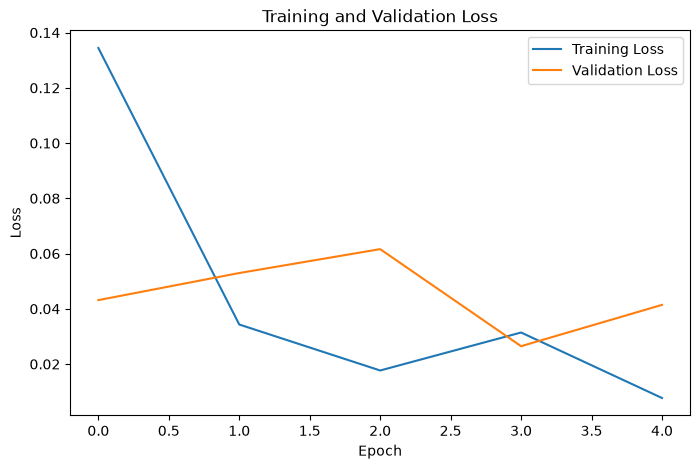

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

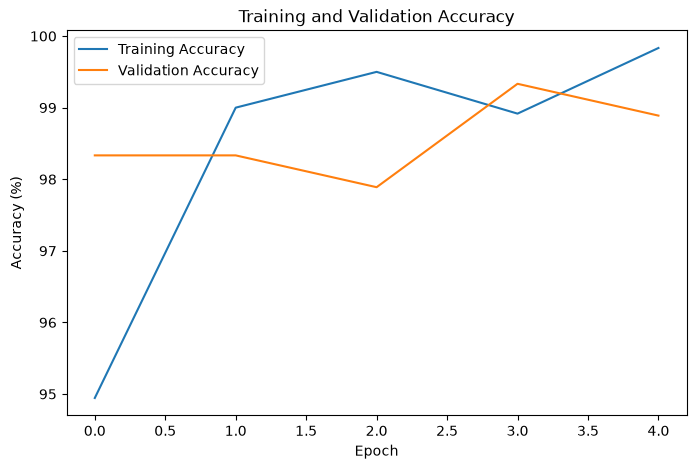

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

In [35]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

In [36]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=train_dataset.classes
    )
)

                       precision    recall  f1-score   support

Tomato___Early_blight       0.95      1.00      0.98       200
 Tomato___Late_blight       1.00      0.97      0.99       382
     Tomato___healthy       1.00      1.00      1.00       318

             accuracy                           0.99       900
            macro avg       0.98      0.99      0.99       900
         weighted avg       0.99      0.99      0.99       900



In [37]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[200   0   0]
 [ 10 372   0]
 [  0   0 318]]


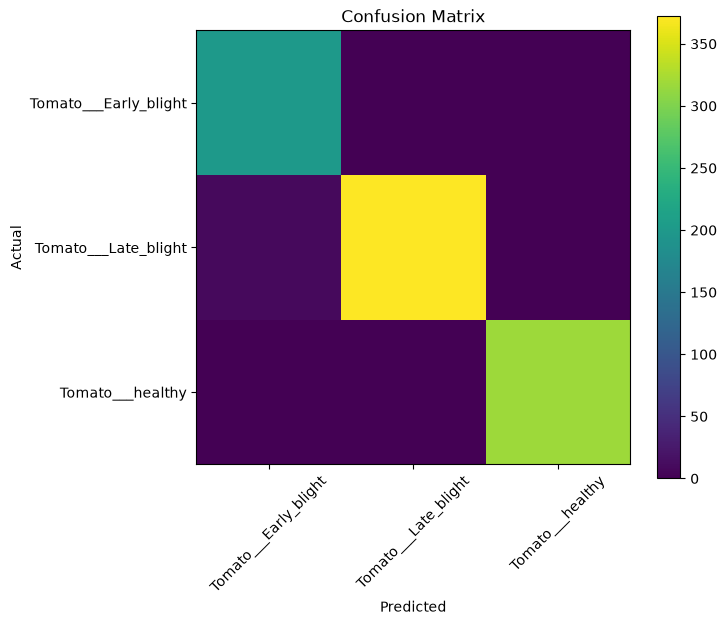

In [38]:
plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.xticks(
    range(len(train_dataset.classes)),
    train_dataset.classes,
    rotation=45
)

plt.yticks(
    range(len(train_dataset.classes)),
    train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

In [39]:
torch.save(
    model.state_dict(),
    "resnet18_tomato.pth"
)

In [46]:
# Select the final convolutional layer of ResNet18
target_layer = model.layer4[-1]

print(target_layer)

BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
)


In [41]:
activations = None
gradients = None

In [42]:
def forward_hook(module, input, output):
    global activations
    activations = output


def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

In [47]:
forward_handle = target_layer.register_forward_hook(forward_hook)

backward_handle = target_layer.register_full_backward_hook(
    backward_hook
)

In [43]:
image, label = val_dataset[0]

input_image = image.unsqueeze(0).to(device)

print("Actual class:", train_dataset.classes[label])

Actual class: Tomato___Early_blight


In [49]:
model.eval()

model.zero_grad()

output = model(input_image)

predicted_class = output.argmax(dim=1).item()

print(
    "Predicted class:",
    train_dataset.classes[predicted_class]
)

score = output[0, predicted_class]

score.backward()

Predicted class: Tomato___Early_blight


In [50]:
weights = gradients.mean(
    dim=(2, 3),
    keepdim=True
)

cam = (weights * activations).sum(
    dim=1
)

cam = torch.relu(cam)

cam = cam.squeeze().detach().cpu().numpy()

cam = cam - cam.min()

cam = cam / (cam.max() + 1e-8)

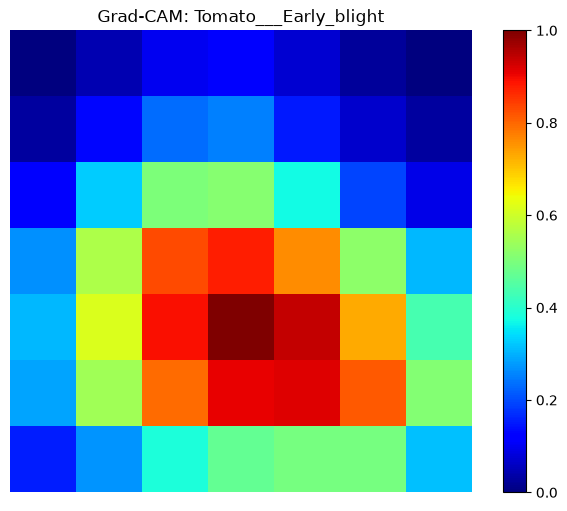

In [51]:
plt.figure(figsize=(8, 6))

plt.imshow(cam, cmap="jet")
plt.colorbar()

plt.title(
    f"Grad-CAM: {train_dataset.classes[predicted_class]}"
)

plt.axis("off")

plt.show()

In [52]:
forward_handle.remove()
backward_handle.remove()